# Apartado 4. Estudio de la media y la varianza de la temperatura en dos grupos de celdas.

## Importación y carga de datos

En esta sección se importan los datos y librerías necesarias para el análisis del Apartado 1.

In [7]:
from carga_de_datos import *
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## 4.1. Basándote en las conclusiones del punto 2.2, forma dos grupos de celdas, de modo que las temperaturas de las celdas de un grupo sean similares entre sí y distintas a las del otro grupo. Justifica la elección de estos dos grupos.

Para contextualizar la elección de los dos grupos, vamos a mostrar el mismo análisis del apartado 2.2:

Matriz correlaciones:
              TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
TEMP_CELDA01       1.00000       0.99989       0.99956       0.99914   
TEMP_CELDA02       0.99989       1.00000       0.99988       0.99932   
TEMP_CELDA03       0.99956       0.99988       1.00000       0.99929   
TEMP_CELDA04       0.99914       0.99932       0.99929       1.00000   
TEMP_CELDA05       0.99868       0.99909       0.99933       0.99977   
TEMP_CELDA06       0.98676       0.98761       0.98828       0.98884   
TEMP_CELDA07       0.98137       0.98230       0.98305       0.98381   
TEMP_CELDA08       0.97699       0.97796       0.97874       0.97966   
TEMP_CELDA09       0.98409       0.98503       0.98589       0.98650   
TEMP_CELDA10       0.97975       0.98073       0.98158       0.98243   

              TEMP_CELDA05  TEMP_CELDA06  TEMP_CELDA07  TEMP_CELDA08  \
TEMP_CELDA01       0.99868       0.98676       0.98137       0.97699   
TEMP_CELDA02       0.99909       0.98761 

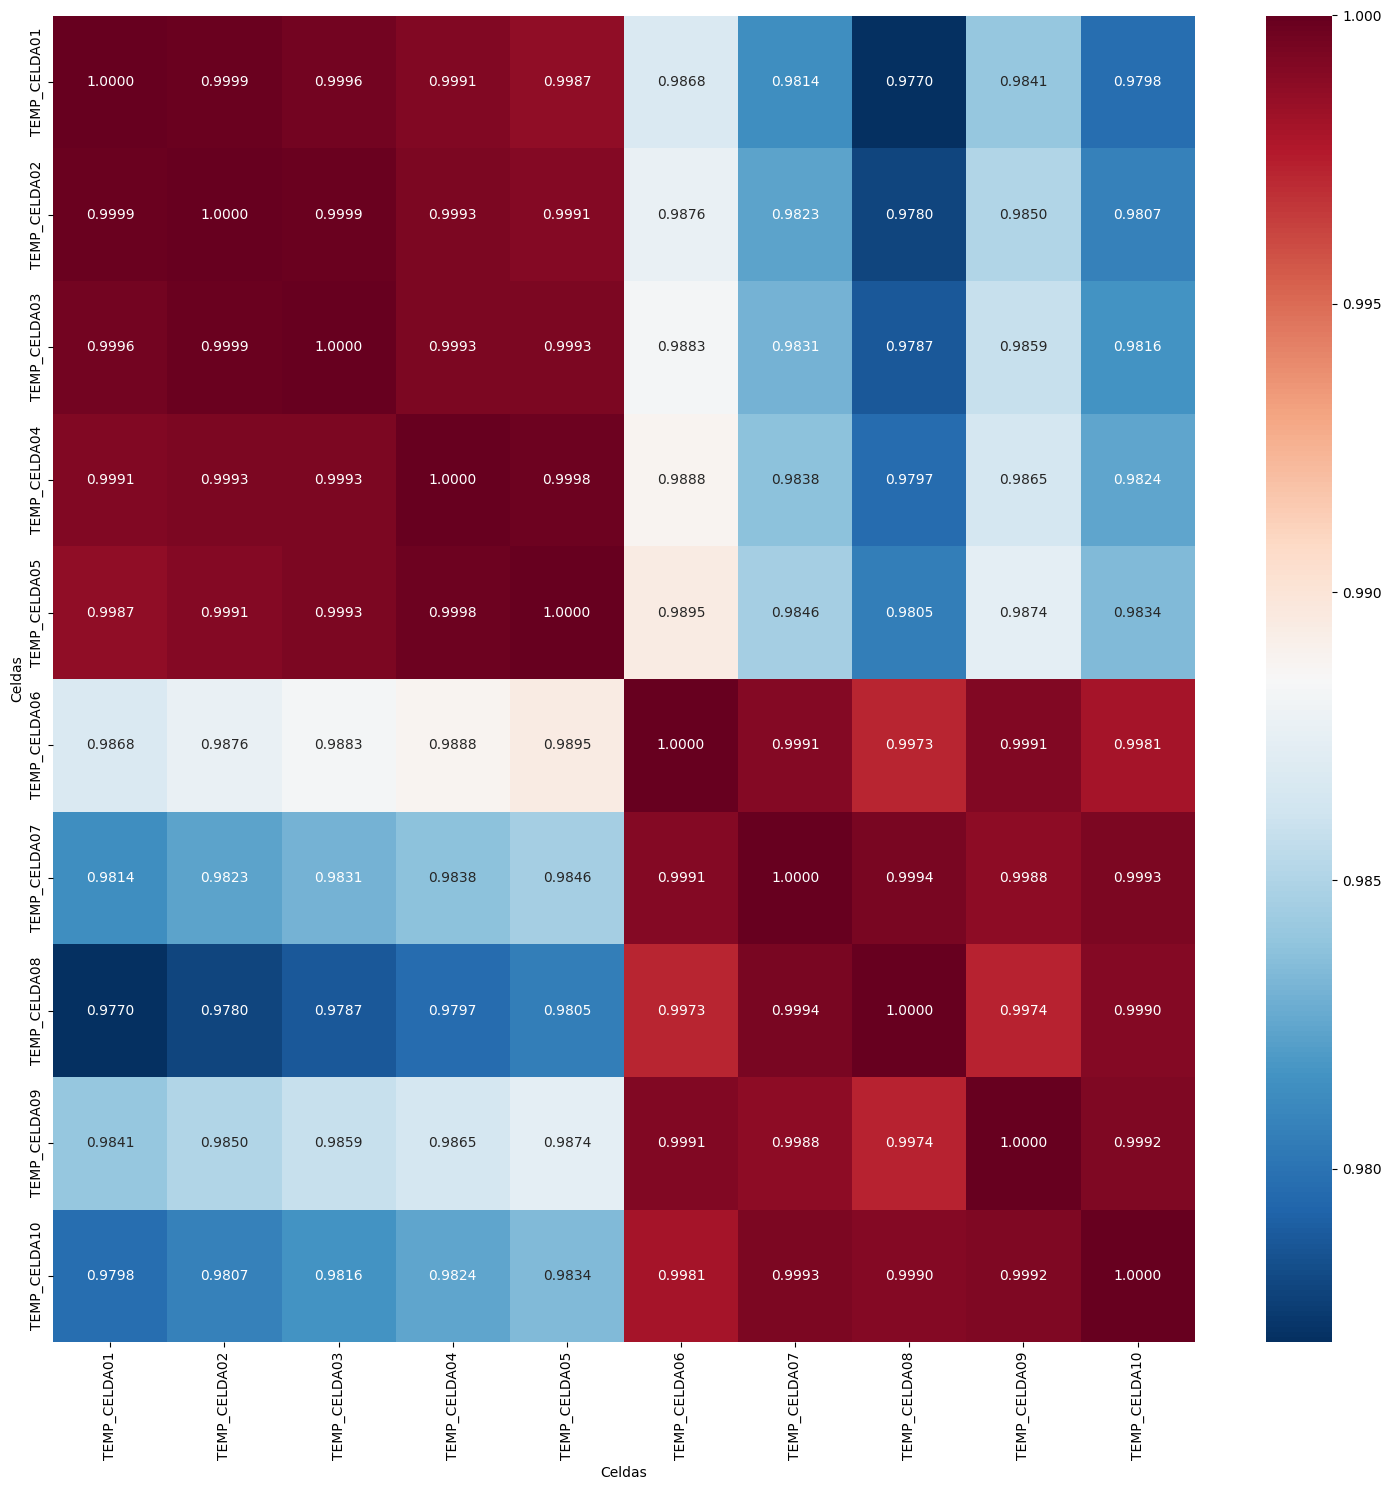

In [ ]:
df_filtrado_temp = df_orig_temp.filter(like='CELDA')

# matriz de correlaciones
mat_corr = df_filtrado_temp.corr()
print('Matriz correlaciones:')
print(np.round(mat_corr, 5))

# Muestra la matriz de correlaciones visualmente
fig = plt.figure(1, figsize=(15, 15))
sns.heatmap(mat_corr, annot=True, fmt='.4f', cmap='RdBu_r') # fmt para redondear a 4 decimales (porque si no la correlación sale como 1 en algunos casos)
plt.xlabel('Celdas')
plt.ylabel('Celdas')
plt.tight_layout()
plt.show()

Podemos ver claramente como hay dos zonas distintas, una en rojo y la otra en blanco y azul. La primera zona está compuesta por las celdas 01-05, y la segunda compuesta por las celdas 06-10. Como ya habíamos empezado a indicar en apartados anteriores, seguramente esto se deba a que los datos elegidos sean de grupos de celdas de dos lugares geográficos diferentes.

## 4.2. Calcula las siguientes cuatro variables y explica cómo lo has hecho: la temperatura media y la varianza de la temperatura para cada uno de los dos grupos de celdas. Pista: cada una de estas cuatro variables es una serie temporal de datos diarios que abarca el rango de fechas original. ¿Qué grupo de celdas tiene las temperaturas más altas? ¿Y qué grupo tiene una temperatura más homogénea entre sus celdas? 

Para generar las variables de temperatura media lo que hago es sumar todas las celdas del grupo y dividir entre el número de celdas.
Para la varianza lo que hago es que creo una nueva lista en la que cada variable de la lista es la varianza de los 5 valores de temperatura de ese grupo.

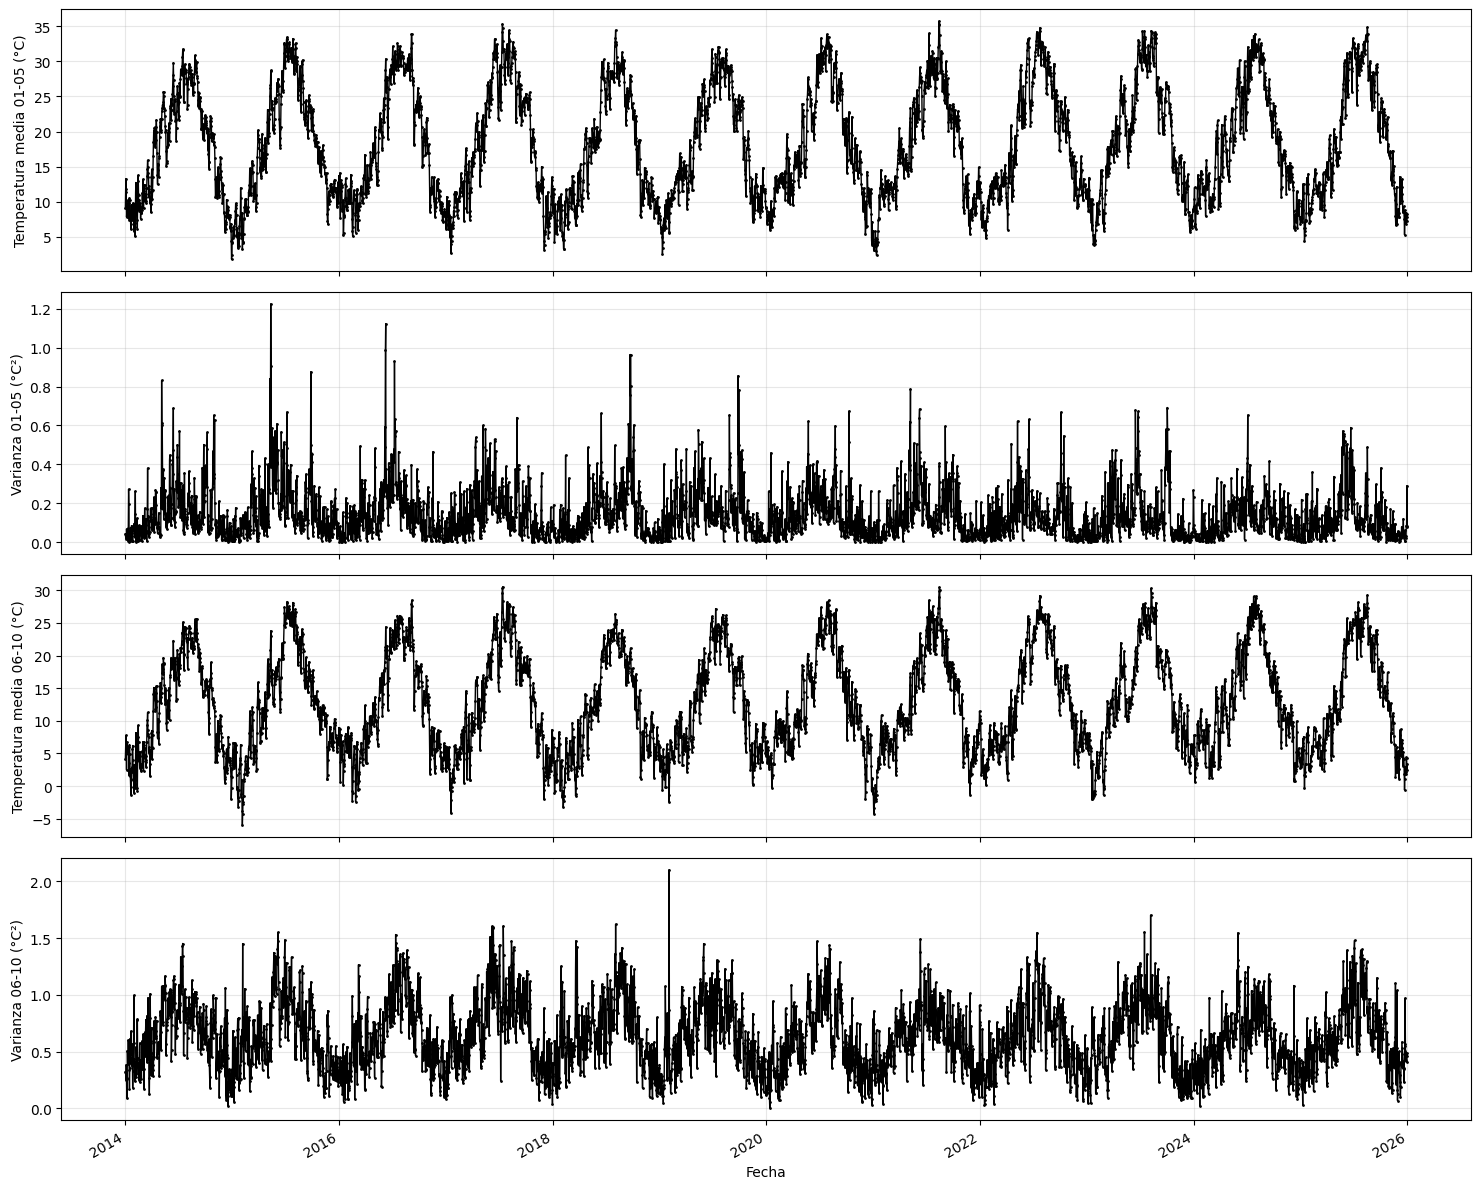

In [9]:
temp_media1 = df_orig_temp["TEMP_CELDA01"].copy()
for i in range(2, 6):
    temp_media1 += df_orig_temp[f"TEMP_CELDA0{i}"]
temp_media1 = temp_media1 / 5

varianza_temp1 = []
for i in range(len(df_orig_temp["TEMP_CELDA01"])):
    x = []
    for j in range(1, 6):
        x.append(df_orig_temp[f"TEMP_CELDA0{j}"].iloc[i])
    varianza_temp1.append(np.var(x))


temp_media2 = df_orig_temp["TEMP_CELDA10"].copy()
for i in range(6, 10):
    temp_media2 += df_orig_temp[f"TEMP_CELDA0{i}"]
temp_media2 = temp_media2 / 5

varianza_temp2 = []
for i in range(len(df_orig_temp["TEMP_CELDA06"])):
    x = []
    for j in range(6, 10):
        x.append(df_orig_temp[f"TEMP_CELDA0{j}"].iloc[i])
    x.append(df_orig_temp[f"TEMP_CELDA10"].iloc[i])
    varianza_temp2.append(np.var(x))


fig, axs = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.subplots_adjust(hspace=0.25)

plots = [temp_media1, varianza_temp1, temp_media2, varianza_temp2]
ylabels = ["Temperatura media 01-05 (°C)", "Varianza 01-05 (°C²)", "Temperatura media 06-10 (°C)", "Varianza 06-10 (°C²)"]

for i in range(4):
    axs[i].plot(df_orig_temp.FECHA, plots[i], 'k.-', markersize=2, linewidth=1)
    axs[i].set_ylabel(ylabels[i])
    axs[i].grid(alpha=0.3)

axs[3].set_xlabel('Fecha')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 4.1： Series temporales de temperatura media y varianza por grupo de celdas.png', dpi=300, bbox_inches='tight')
plt.show()

Podemos ver que el grupo de celdas 01-05 tiene una temperatura más homogénea, ya que la varianza se sitúa consistentemente por debajo de la del otro grupo. Para la temperatura no lo veo claramente, así que voy a realizar otro gráfico complementario.

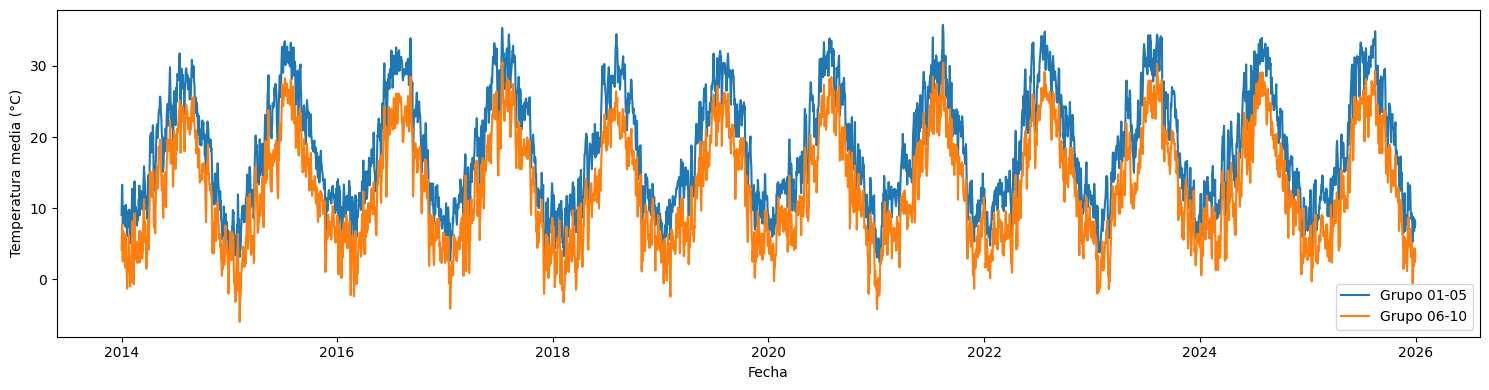

In [10]:
fig = plt.figure(1, figsize=(15, 4))
# Temperatura
plt.plot(df_orig_temp.FECHA, temp_media1, label='Grupo 01-05')
plt.plot(df_orig_temp.FECHA, temp_media2, label='Grupo 06-10')
plt.xlabel('Fecha')
plt.ylabel('Temperatura media (°C)')
plt.legend(title=None)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 4.2： Evolución temporal de la temperatura media en los grupos 01-05 y 06-10.png', dpi=300, bbox_inches='tight')
plt.show()


Vemos que el grupo de celdas 01-05 tiene una temperatura consistentemente más alta a lo largo de todo el periodo en el que se han tomado medidas.

## 4.3. ¿Cómo cambia la correlación entre las temperaturas medias de los dos grupos con los meses? ¿En qué mes las temperaturas medias están más correlacionadas? ¿Y en cuál lo están menos?


Tabla Mes-Correlación:
Mes  Correlación
Ene     0.849542
Feb     0.921450
Mar     0.940866
Abr     0.954512
May     0.940712
Jun     0.922275
Jul     0.862272
Ago     0.878944
Sep     0.918536
Oct     0.949120
Nov     0.928528
Dic     0.854948


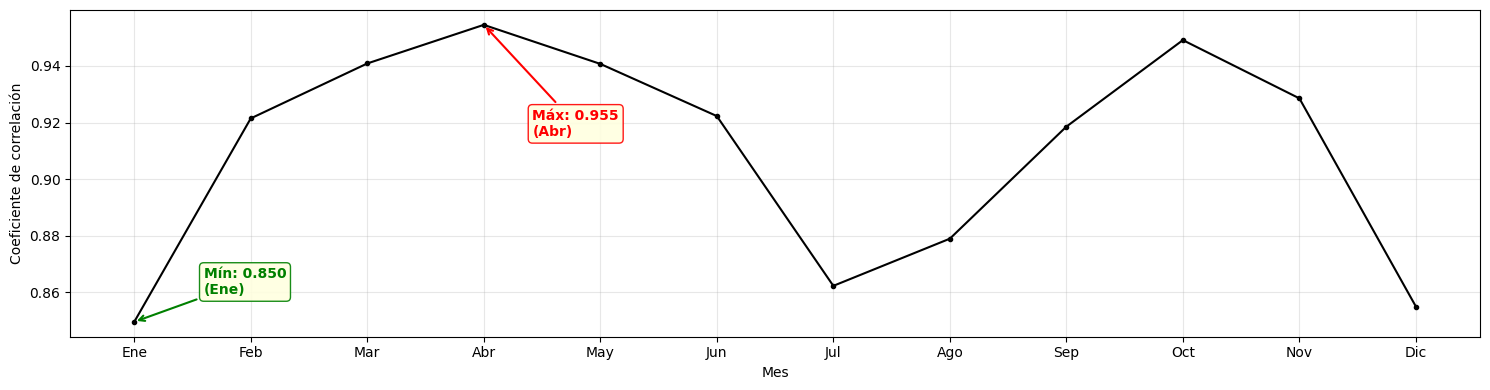

In [11]:
months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

df_unido = pd.DataFrame(np.column_stack((df_orig_temp.FECHA, temp_media1, temp_media2)), columns=["FECHA", "Grupo 1", "Grupo 2"])
df_unido['FECHA'] = pd.to_datetime(df_unido['FECHA'])
df_unido['MES'] = df_unido['FECHA'].dt.month

correlaciones = []
for mes, data in df_unido.groupby("MES"):
    correlaciones.append((mes, data["Grupo 1"].corr(data["Grupo 2"])))

corr_month = pd.DataFrame(correlaciones, columns=["MES", "corr"]).sort_values("MES")
corr_month["MES"] = corr_month["MES"].map(lambda m: months_labels[m - 1])
corr_month.rename(columns={"MES": "Mes", "corr": "Correlación"}, inplace=True)
corr_month.reset_index(drop=True, inplace=True)

print("\nTabla Mes-Correlación:")
print(corr_month.to_string(index=False))

idx_max = corr_month["Correlación"].idxmax()
idx_min = corr_month["Correlación"].idxmin()
mes_max = corr_month.loc[idx_max, "Mes"]
mes_min = corr_month.loc[idx_min, "Mes"]
val_max = corr_month.loc[idx_max, "Correlación"]
val_min = corr_month.loc[idx_min, "Correlación"]

fig = plt.figure(1, figsize=(15, 4)) # permite indicar el nº de la figura y las dimensiones (ancho y alto)
plt.plot(corr_month["Correlación"], 'k.-')            # muestra la variable en negro, cada valor con un punto conectado por líneas
plt.xticks(range(0, 12), corr_month["Mes"])

plt.annotate(f"Mín: {val_min:.3f}\n({mes_min})",
             xy=(idx_min, val_min),
             xytext=(50, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

plt.annotate(f"Máx: {val_max:.3f}\n({mes_max})",
             xy=(idx_max, val_max),
             xytext=(35, -80), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.xlabel('Mes')
plt.ylabel('Coeficiente de correlación')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 4.3： Correlación mensual entre las temperaturas medias de los grupos de celdas.png', dpi=300, bbox_inches='tight')
plt.show()

Vemos que las temperaturas suelen estar más correlacionadas durante primavera y otoño que durante el resto del año. En cualquier caso, la correlación es muy alta todos los meses (por encima de 0.84). El mes con mayor correlación es abril (0.955) y el de menor correlación es enero (0.849). Esto sugiere que en primavera y otoño las variaciones de temperatura entre ambos grupos de celdas siguen patrones más similares, mientras que en invierno y verano pueden aparecer diferencias algo mayores entre celdas.

## 4.4. Responde a la pregunta anterior (punto 4.3) usando como variables las varianzas de la temperatura de los dos grupos.


Tabla Mes-Correlación:
Mes  Correlación
Ene     0.132580
Feb     0.057941
Mar    -0.001194
Abr     0.317735
May     0.332894
Jun     0.314130
Jul     0.262164
Ago     0.024391
Sep     0.201593
Oct     0.449527
Nov     0.161092
Dic     0.161782


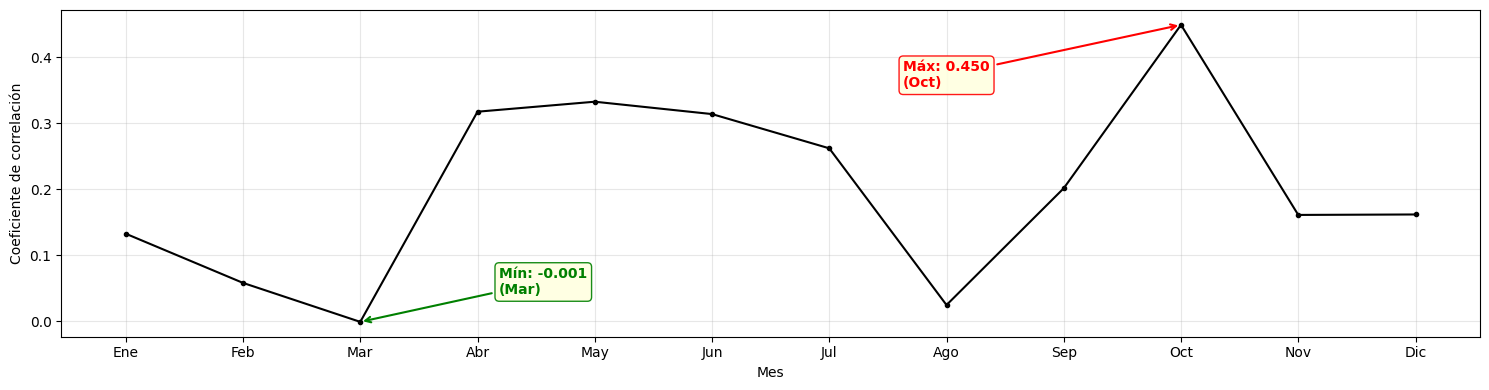

In [12]:
months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

df_unido = pd.DataFrame(np.column_stack((df_orig_temp.FECHA, varianza_temp1, varianza_temp2)), columns=["FECHA", "Grupo 1", "Grupo 2"])
df_unido['FECHA'] = pd.to_datetime(df_unido['FECHA'])
df_unido['MES'] = df_unido['FECHA'].dt.month

correlaciones = []
for mes, data in df_unido.groupby("MES"):
    correlaciones.append((mes, data["Grupo 1"].corr(data["Grupo 2"])))

corr_month = pd.DataFrame(correlaciones, columns=["MES", "corr"]).sort_values("MES")
corr_month["MES"] = corr_month["MES"].map(lambda m: months_labels[m - 1])
corr_month.rename(columns={"MES": "Mes", "corr": "Correlación"}, inplace=True)
corr_month.reset_index(drop=True, inplace=True)

print("\nTabla Mes-Correlación:")
print(corr_month.to_string(index=False))

idx_max = corr_month["Correlación"].idxmax()
idx_min = corr_month["Correlación"].idxmin()
mes_max = corr_month.loc[idx_max, "Mes"]
mes_min = corr_month.loc[idx_min, "Mes"]
val_max = corr_month.loc[idx_max, "Correlación"]
val_min = corr_month.loc[idx_min, "Correlación"]

fig = plt.figure(1, figsize=(15, 4)) # permite indicar el nº de la figura y las dimensiones (ancho y alto)
plt.plot(corr_month["Correlación"], 'k.-')            # muestra la variable en negro, cada valor con un punto conectado por líneas
plt.xticks(range(0, 12), corr_month["Mes"])

plt.annotate(f"Mín: {val_min:.3f}\n({mes_min})",
             xy=(idx_min, val_min),
             xytext=(100, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='green', alpha=0.9))

plt.annotate(f"Máx: {val_max:.3f}\n({mes_max})",
             xy=(idx_max, val_max),
             xytext=(-200, -45), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red', alpha=0.9))

plt.xlabel('Mes')
plt.ylabel('Coeficiente de correlación')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'Gráfico 4.4： Correlación mensual entre las varianzas de temperatura de los grupos de celdas.png', dpi=300, bbox_inches='tight')
plt.show()

La varianza no sigue patrones muy claros, pero vemos que sube a principios del verano, y en octubre, y se mantiene abajo durante agosto y todo el invierno.
El més en el que más correlacionadas están las varianzas es octubre (con 0.450), y el que menos marzo (-0.001).